## Notes for Sureksha:
- I created functions to load well files (a single horizontal file, randomly, with its corresponding Typewell file)
- I then analysed the datasets with .info(), .describe() etc
- plotted to visualise

## GR shape comparison — Typewell vs Horizontal well

This plots GR vs TVT (typewell) and GR vs MD (horizontal well) side by side, normalized
onto the same 0–1 axis just to visually check that the two GR curves look similar in shape.

<div style="background-color:#e6f4ea; border-left:5px solid #34a853; padding:10px; border-radius:4px;">
<b>Update:</b> I've started writing <code>process_well</code>, a function that takes one well's horizontal
and typewell data and processes them together. For each well, it slides a window of the horizontal
well's GR values across the typewell's GR curve, scores how well each position matches (cross-correlation),
and finds the best-matching TVT for each window. That matched TVT — plus a confidence/correlation score —
gets assigned to the center row of the window, as two new columns (<code>matched_TVT</code>, <code>matched_score</code>)
in the horizontal well's dataframe.

Still need to finish the <b>rolling window / feature engineering</b> part (local averages/trends over
nearby rows, to give the model some sense of sequence without needing a sequence model).

Once <code>process_well</code> is complete, we'll loop it over every well, and each processed well gets
concatenated together — so we end up with one big horizontal dataset (one row per point, across all wells)
to train the model (LightGBM) with.

🛎️ Ping me if still not clear, or if you want to propose a different way or additional step before this ;)
</div>

# 1. Dependencies 

In [1]:
# import all libraries and functions here ...
import pandas as pd 
import numpy as np 
import os
import glob
import random 
import matplotlib.pyplot as plt
from scipy.signal import correlate 

# 2. Exploratory Data Analysis 

In [2]:
# constants
#directories
DATA_DIR = "/kaggle/input/competitions/rogii-wellbore-geology-prediction"
TRAIN_DIR = DATA_DIR + "/train"
TEST_DIR = DATA_DIR + "/test"

#files
HORIZONTAL_FILES = glob.glob(os.path.join(TRAIN_DIR + "/" + "*__horizontal_well.csv"))
TYPEWELL_FILES = glob.glob(os.path.join(TRAIN_DIR + "/" + "*__typewell.csv"))

WINDOW = 25

In [3]:
# code to see all files in the data/ input directory 
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/AI_wellbore_geology_prediction_task_en.pptx
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/75d20a82__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b0f53bf4__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/e47

In [4]:
# check horizontal csv file 
def get_horizontal_file():
    file_path = random.choice(HORIZONTAL_FILES)
    df = pd.read_csv(file_path)
    well_ID = os.path.basename(file_path).split("__")[0]
    df['WELL_ID'] = well_ID
    return df, well_ID

In [5]:
# check typewell csv file 
def get_typewell_file():
    file_path = random.choice(TYPEWELL_FILES)
    df = pd.read_csv(file_path)
    well_ID = ps.path.basename(file_path).split("__")[0]
    df['WELL_ID'] = well_ID
    return df 

In [6]:
# get matching typewell file 
def get_matching_files():
    horizontal_df, well_ID  = get_horizontal_file()
    typewell_file = os.path.join(TRAIN_DIR + "/" + f"{well_ID}__typewell.csv")
    typewell_df = pd.read_csv(typewell_file)
    return horizontal_df, well_ID,typewell_df

In [7]:
h_df, ID , tw_df = get_matching_files()

In [8]:
h_df.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELL_ID
0,10786.0,3004782.61,1117089.43,-8608.9,-8935.73,-9070.08,-9152.64,-9287.16,-9337.71,-9443.58,10607.19,NaN,10607.19,512943b2
1,10787.0,3004782.60,1117089.44,-8609.9,-8935.73,-9070.08,-9152.64,-9287.16,-9337.71,-9443.58,10608.19,NaN,10608.19,512943b2
2,10788.0,3004782.59,1117089.44,-8610.9,-8935.73,-9070.08,-9152.64,-9287.16,-9337.71,-9443.58,10609.19,NaN,10609.19,512943b2
3,10789.0,3004782.58,1117089.45,-8611.9,-8935.73,-9070.08,-9152.64,-9287.16,-9337.71,-9443.58,10610.19,NaN,10610.19,512943b2
4,10790.0,3004782.56,1117089.45,-8612.9,-8935.73,-9070.08,-9152.64,-9287.16,-9337.71,-9443.58,10611.19,NaN,10611.19,512943b2


In [9]:
tw_df.head()

,TVT,GR,Geology
0,10594.91,111.38,NaN
1,10595.41,110.74,NaN
2,10595.91,108.85,NaN
3,10596.41,109.01,NaN
4,10596.91,111.66,NaN


In [10]:
h_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6681 entries, 0 to 6680
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         6681 non-null   float64
 1   X          6681 non-null   float64
 2   Y          6681 non-null   float64
 3   Z          6681 non-null   float64
 4   ANCC       6681 non-null   float64
 5   ASTNU      6681 non-null   float64
 6   ASTNL      6681 non-null   float64
 7   EGFDU      6681 non-null   float64
 8   EGFDL      6681 non-null   float64
 9   BUDA       6681 non-null   float64
 10  TVT        6681 non-null   float64
 11  GR         1814 non-null   float64
 12  TVT_input  1652 non-null   float64
 13  WELL_ID    6681 non-null   object 
dtypes: float64(13), object(1)
memory usage: 730.9+ KB


In [11]:
h_df.describe()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
count,6681.000000,6.681000e+03,6.681000e+03,6681.000000,6681.000000,6681.000000,6681.000000,6681.000000,6681.000000,6681.000000,6681.000000,1814.000000,1652.000000
mean,14126.000000,3.004608e+06,1.114260e+06,-9360.921995,-8977.642480,-9111.992760,-9194.551027,-9329.074549,-9379.622226,-9485.499350,11317.302296,101.436651,11193.625345
std,1928.782906,8.027652e+01,1.887478e+03,162.438506,57.463455,57.463453,57.463507,57.463441,57.463446,57.463494,132.601649,23.569556,225.331567
min,10786.000000,3.004500e+06,1.110950e+06,-9510.040000,-9092.970000,-9227.320000,-9309.880000,-9444.400000,-9494.950000,-9600.830000,10607.190000,37.292232,10607.190000
25%,12456.000000,3.004546e+06,1.112617e+06,-9451.760000,-9027.130000,-9161.480000,-9244.030000,-9378.560000,-9429.100000,-9534.980000,11353.100000,86.875345,11053.775000
50%,14126.000000,3.004610e+06,1.114283e+06,-9394.440000,-8968.500000,-9102.850000,-9185.410000,-9319.930000,-9370.480000,-9476.360000,11358.750000,100.220315,11334.010000
75%,15796.000000,3.004629e+06,1.115952e+06,-9352.120000,-8928.670000,-9063.020000,-9145.580000,-9280.100000,-9330.650000,-9436.520000,11359.760000,121.209988,11359.360000
max,17466.000000,3.004783e+06,1.117090e+06,-8608.900000,-8889.840000,-9024.190000,-9106.750000,-9241.270000,-9291.820000,-9397.700000,11365.150000,199.417243,11360.300000


In [12]:
tw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1887 entries, 0 to 1886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TVT      1887 non-null   float64
 1   GR       1887 non-null   float64
 2   Geology  1208 non-null   object 
dtypes: float64(2), object(1)
memory usage: 44.4+ KB


In [13]:
tw_df['Geology']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
1882    BUDA
1883    BUDA
1884    BUDA
1885    BUDA
1886    BUDA
Name: Geology, Length: 1887, dtype: object

In [14]:
# another well 
h_df_1, _, tw_df_1 = get_matching_files()

In [15]:
h_df_1.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELL_ID
0,10984.0,3007274.18,1105424.14,-8825.64,-9353.13,-9509.36,-9582.30,-9716.86,-9760.89,-9880.98,11040.19,NaN,11040.19,d924e971
1,10985.0,3007274.14,1105424.14,-8826.64,-9353.13,-9509.35,-9582.29,-9716.85,-9760.89,-9880.98,11041.20,NaN,11041.20,d924e971
2,10986.0,3007274.09,1105424.14,-8827.64,-9353.12,-9509.35,-9582.29,-9716.84,-9760.88,-9880.97,11042.20,NaN,11042.20,d924e971
3,10987.0,3007274.05,1105424.14,-8828.64,-9353.12,-9509.34,-9582.28,-9716.84,-9760.87,-9880.96,11043.20,NaN,11043.20,d924e971
4,10988.0,3007274.00,1105424.14,-8829.64,-9353.11,-9509.34,-9582.28,-9716.83,-9760.87,-9880.96,11044.21,NaN,11044.21,d924e971


In [16]:
h_df_1.shape

(5308, 14)

In [17]:
h_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5308 entries, 0 to 5307
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         5308 non-null   float64
 1   X          5308 non-null   float64
 2   Y          5308 non-null   float64
 3   Z          5308 non-null   float64
 4   ANCC       5308 non-null   float64
 5   ASTNU      5308 non-null   float64
 6   ASTNL      5308 non-null   float64
 7   EGFDU      5308 non-null   float64
 8   EGFDL      5308 non-null   float64
 9   BUDA       5308 non-null   float64
 10  TVT        5308 non-null   float64
 11  GR         4734 non-null   float64
 12  TVT_input  2124 non-null   float64
 13  WELL_ID    5308 non-null   object 
dtypes: float64(13), object(1)
memory usage: 580.7+ KB


In [18]:
tw_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4518 entries, 0 to 4517
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TVT      4518 non-null   float64
 1   GR       4518 non-null   float64
 2   Geology  2358 non-null   object 
dtypes: float64(2), object(1)
memory usage: 106.0+ KB


In [19]:
def plot_x_y(x, y, x_label , y_label, title):
    plt.figure(figsize = (20,8))
    plt.plot(x, y, linewidth = 0.8)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, alpha = 0.3)
    plt.show()

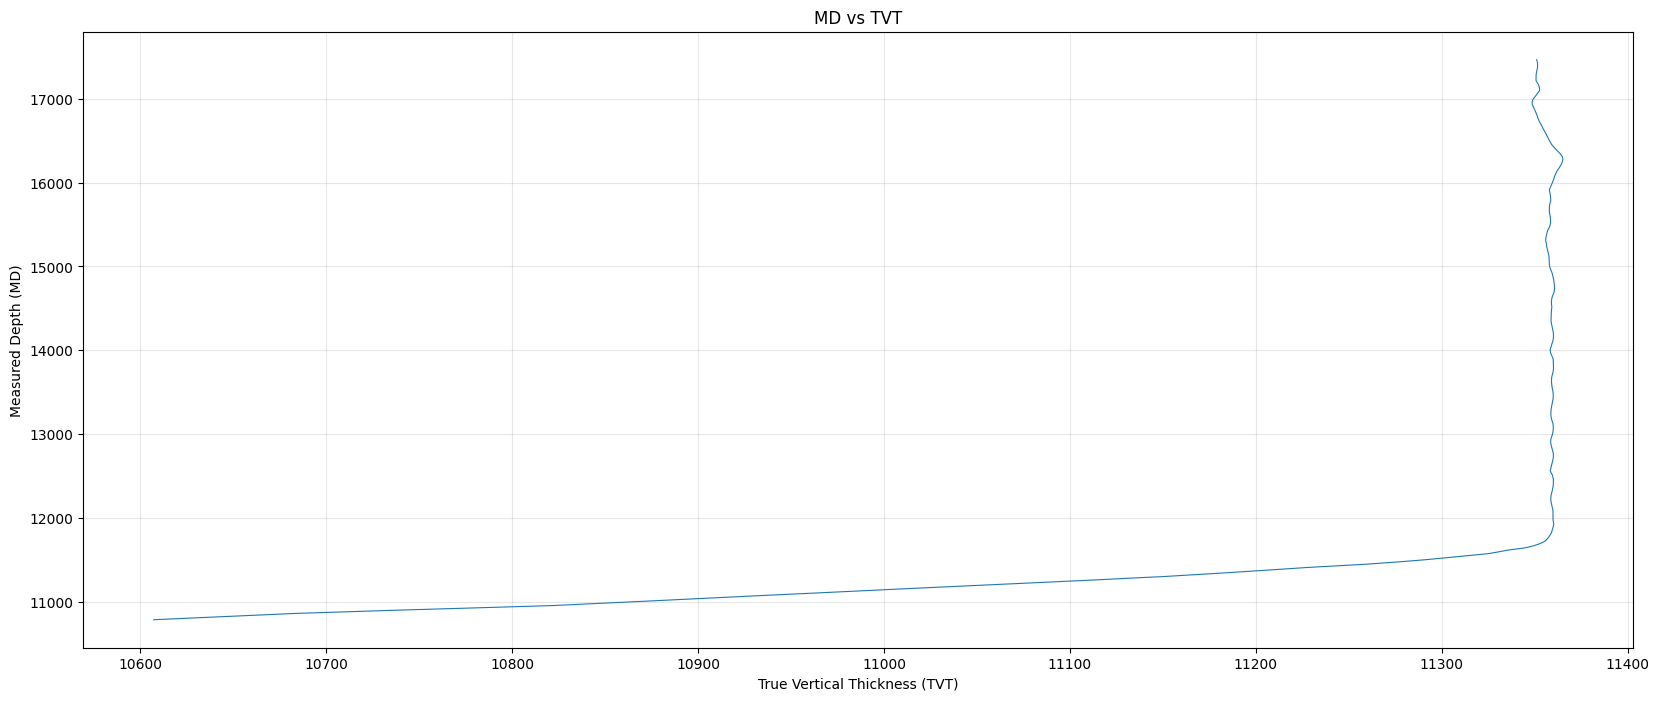

In [20]:
# MD against TVT 
# illustrates where the horizontal drilling starts (?)
plot_x_y(h_df['TVT'], h_df['MD'], "True Vertical Thickness (TVT)", "Measured Depth (MD)", "MD vs TVT")

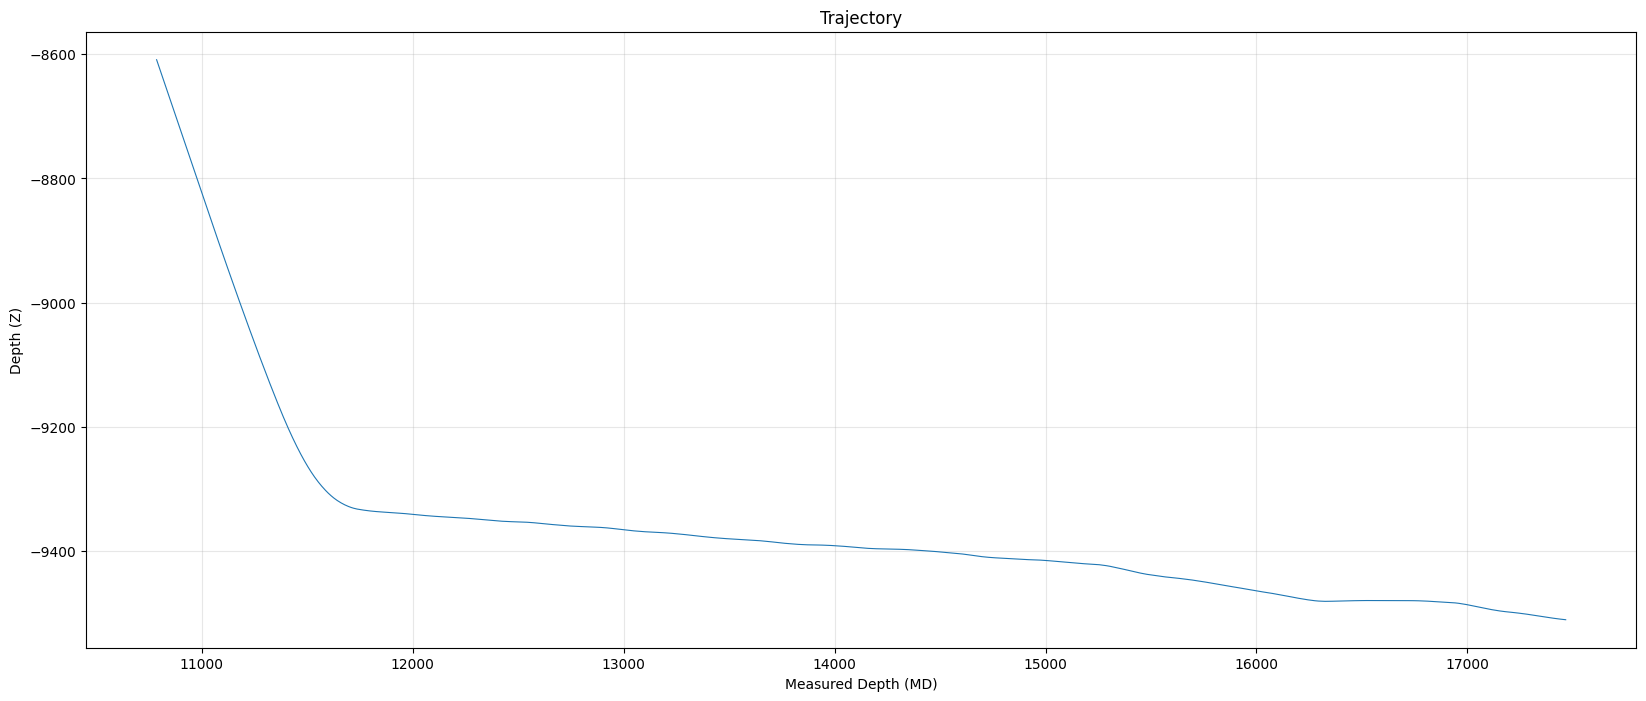

In [21]:
# y against x 
plot_x_y(h_df['MD'], h_df['Z'], "Measured Depth (MD)", "Depth (Z)", "Trajectory")

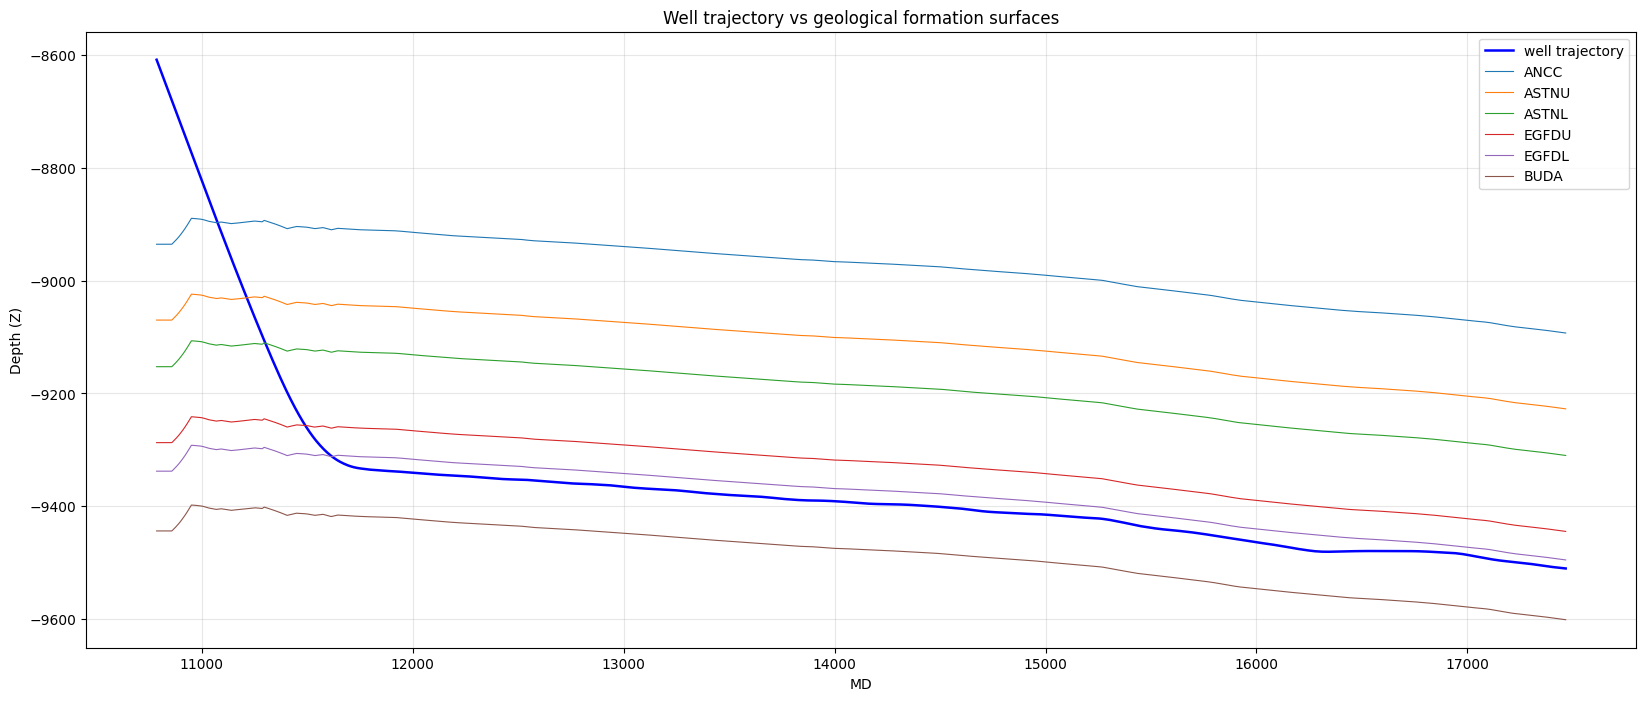

In [22]:
plt.figure(figsize=(20, 8))
plt.plot(h_df['MD'], h_df['Z'], linewidth=1.8, label='well trajectory', color='blue')
plt.plot(h_df['MD'], h_df['ANCC'], linewidth=0.8, label='ANCC')
plt.plot(h_df['MD'], h_df['ASTNU'], linewidth=0.8, label='ASTNU')
plt.plot(h_df['MD'], h_df['ASTNL'], linewidth=0.8, label='ASTNL')
plt.plot(h_df['MD'], h_df['EGFDU'], linewidth=0.8, label='EGFDU')
plt.plot(h_df['MD'], h_df['EGFDL'], linewidth=0.8, label='EGFDL')
plt.plot(h_df['MD'], h_df['BUDA'], linewidth=0.8, label='BUDA')
plt.xlabel("MD")
plt.ylabel("Depth (Z)")
plt.title("Well trajectory vs geological formation surfaces")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

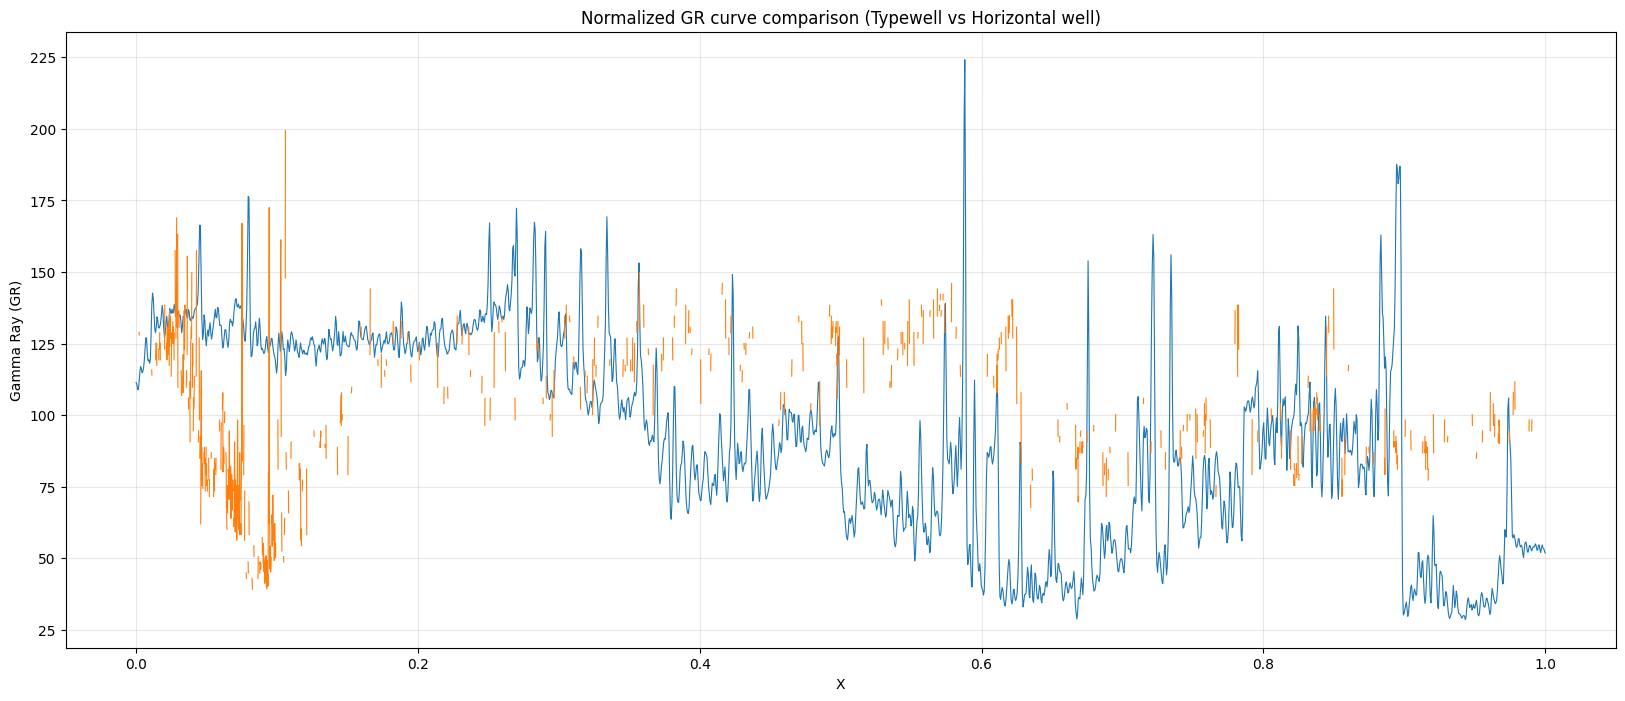

In [23]:
# Quick visual check: do the two GR curves have a similar shape/pattern?
# This does NOT find the actual TVT match — it's just eyeballing texture before
# building the real sliding-window correlation function.

# normalising for a cleaner look 
tw_norm = (tw_df['TVT']- tw_df['TVT'].min())/ (tw_df['TVT'].max() - tw_df['TVT'].min())
h_norm = (h_df['MD'] - h_df['MD'].min()) / (h_df['MD'].max() - h_df['MD'].min())

#plotting 
plt.figure(figsize = (20,8))
plt.plot(tw_norm, tw_df['GR'], linewidth = 0.8 , label = 'Typewell GR')
plt.plot(h_norm, h_df['GR'], linewidth = 0.8, label = 'Horizontal Well GR')
plt.xlabel("X")
plt.ylabel("Gamma Ray (GR)")
plt.title("Normalized GR curve comparison (Typewell vs Horizontal well)")
plt.grid(True, alpha = 0.3)
plt.show()


# 3. Data Proprocessing 

Before we can train anything, we need to turn each well's raw files into one clean table the model can actually learn from. Here's what we're doing for each well:

**Matching horizontal well points to the typewell.**
The horizontal well and typewell are two separate logs — they don't line up row by row, so we can't just merge them directly. Instead, we slide the horizontal well's GR curve across the typewell's GR curve to find where the patterns line up best (cross-correlation). Wherever we find a strong match, we grab the corresponding TVT from the typewell and attach it to that row, along with a score telling us how confident that match is.

**Adding a few engineered features.**
Since the data is sequential (each row depends a bit on the ones around it), we add some rolling-window features — basically local averages/trends over the last few rows — so the model gets a sense of what's happening nearby, not just at a single isolated point.

**Not bothering with missing values.**
There are NaNs scattered through the data, but we're not filling or dropping them — LightGBM handles missing values on its own during training, so it's one less thing to worry about.

**One exception: GR needs to be NaN-free just for the matching step.**
Cross-correlation breaks completely if there's even one NaN in the window, so we make a separate interpolated copy of GR purely to run the matching on. We don't touch the original GR column — that one keeps its real gaps and is what actually goes into the model.

In [24]:
# function to normalize arrays
def normalize(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-8)

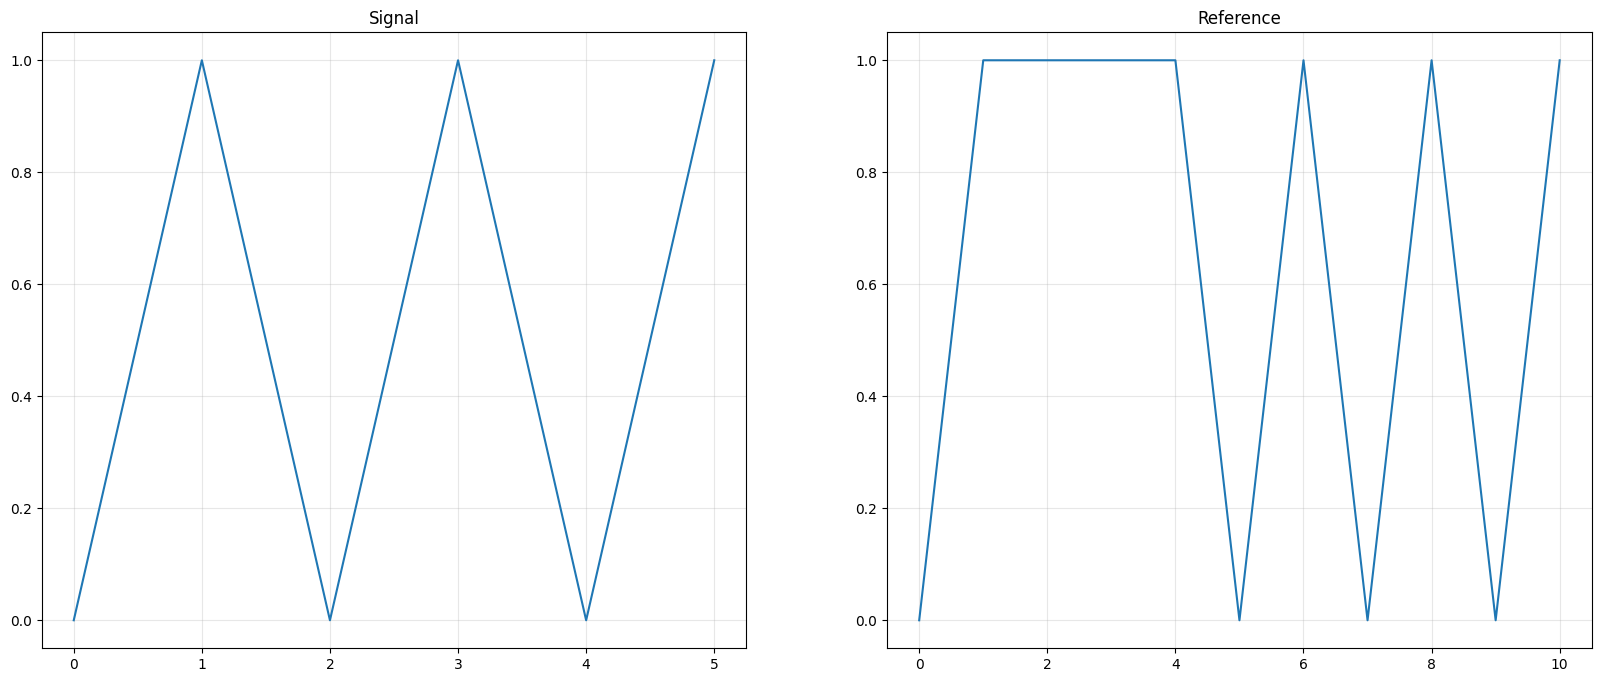

Correlation values:  [ 0.          2.07880452 -4.15760903  4.15760903 -6.23641355  6.23641355]
matched_place:  5


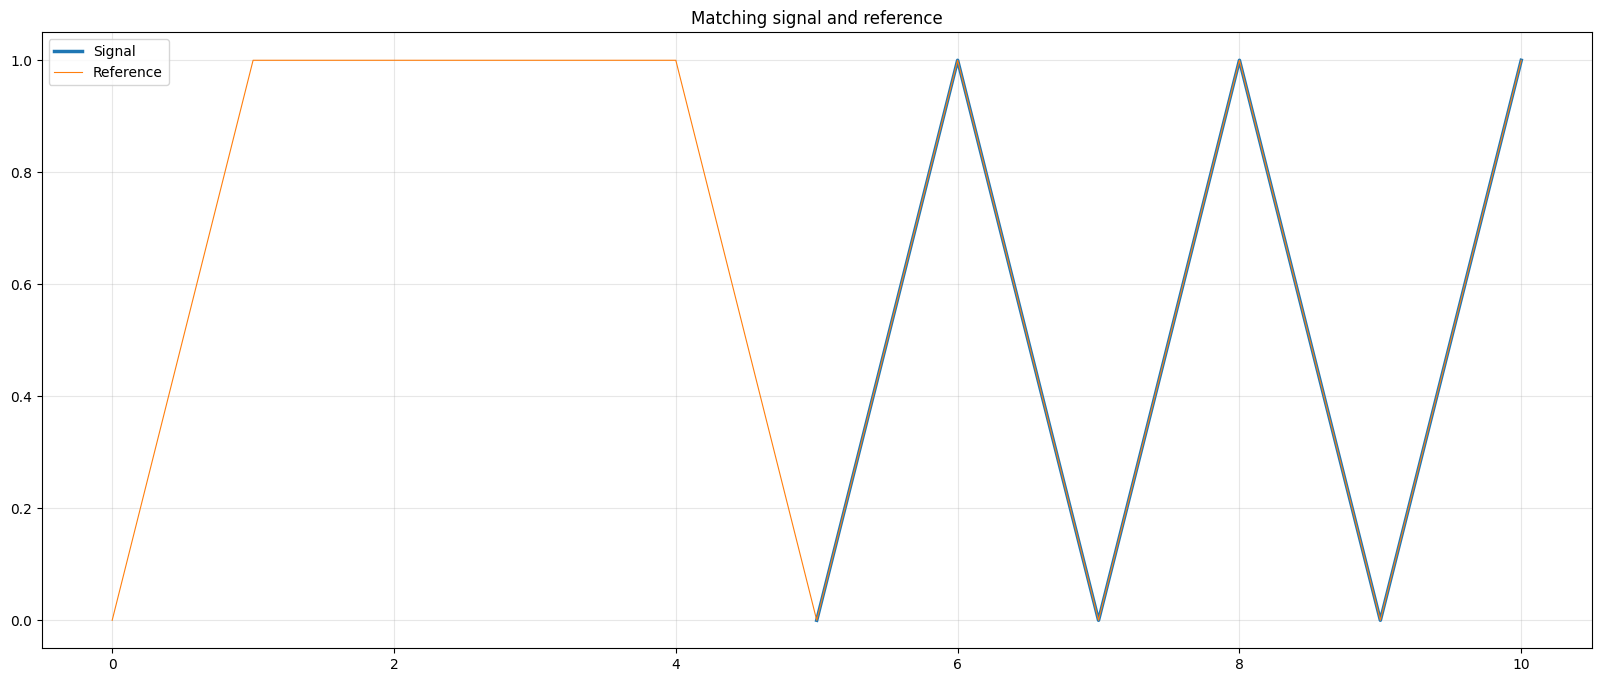

In [25]:
# dummy example to understand scipy.signal.correlate()
signal = np.array([0,1,0,1,0,1], dtype = int)
reference = np.array([0,1,1,1,1,0,1,0,1,0,1], dtype = int) # where we are looking for similar patterns

# plotting the two before matching
plt.figure(figsize = (20,8))
plt.subplot(1,2,1)
plt.plot(signal)
plt.title("Signal")
plt.grid(True, alpha = 0.3)
plt.subplot(1,2,2)
plt.plot(reference)
plt.title("Reference")
plt.grid(True, alpha = 0.3)
plt.show()

n_signal = normalize(signal)
n_reference = normalize(reference)

corr = correlate(n_reference, n_signal, mode = 'valid')
print("Correlation values: ", corr)
matched_place = np.argmax(corr) # where the signal starts matching the reference 
print("matched_place: ", matched_place)


# x axis 
signal_x = np.arange(matched_place, matched_place + len(signal)) # this is for shifting to start from matched place
reference_x = np.arange(len(reference))

# plotting 
plt.figure(figsize= (20,8))
plt.plot(signal_x, signal, linewidth = 2.5, label = 'Signal')
plt.plot(reference_x, reference, linewidth = 0.8, label = 'Reference')
plt.title("Matching signal and reference")
plt.grid(True, alpha = 0.3)
plt.legend()
plt.show()

### Applying this to the real data.

We'll do the same thing with the actual GR values: use matched_place to find the corresponding index in the typewell, then pull out its TVT and assign it to that row in the horizontal well dataset.


The difference is we won't take the whole array of GR values — we'll slide a small window of GR values at a time, for more precision. Each window produces one matched TVT and one confidence/correlation score, which we'll store in two new columns: matched_tvt and match_score.


Since each window covers several rows but only produces one matched value, we'll assign that value to the center row of the window, rather than to every row it covers — that gives the most representative position for the match. Do not worry about the rest of Matched TVT rows, they will get filled as the window slides :)

In [26]:
# creating a function to process each well datasets separately. 
def process_well(h_df, well_ID, tw_df):
    # remove nan from GR columns first for cross correlation 
    h_GR_clean = h_df['GR'].interpolate(limit_direction = 'both')
    tw_GR_clean = tw_df['GR'].interpolate(limit_direction= 'both')
    
    norm_h_GR = normalise(h_GR_clean)
    norm_tw_GR = normalise(tw_GR_clean)

    # initialise the new columns in horizontal file 
    h_df['matched_TVT'] = np.full(len(norm_h_GR), np.nan)
    h_df['matched_score'] = np.full(len(norm_h_GR), np.nan)
    
    # cross-correlation 
    for i in range(0,len(norm_h_GR)- WINDOW):
        h_seq = norm_h_GR[i:i + WINDOW]
        corr = correlate(norm_tw_GR, h_seq, mode = 'valid')
        matched_place = np.argmax(corr)
        confidence_score = corr[matched_place]
        centre = (i + WINDOW ) // 2

        # assign it to columns
        h_df.loc[centre, 'matched_TVT'] = tw_df['TVT'].iloc[(matched_place + WINDOW) //2]
        h_df.loc[centre, 'matched_score'] = confidence_score
        
    # add rolling window features 

# 4. Modeling

# 5. Evaluation